<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 19.2 KB


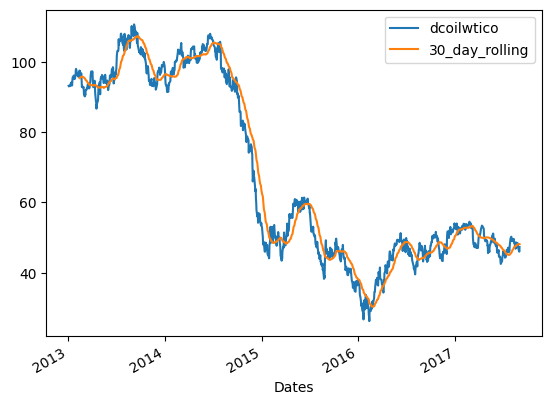

Month with highest average:  2013-08-31 00:00:00


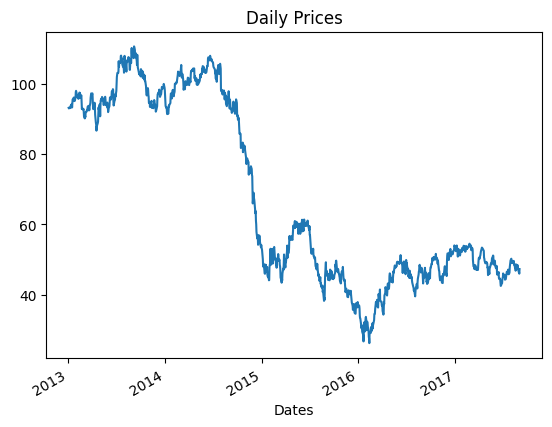

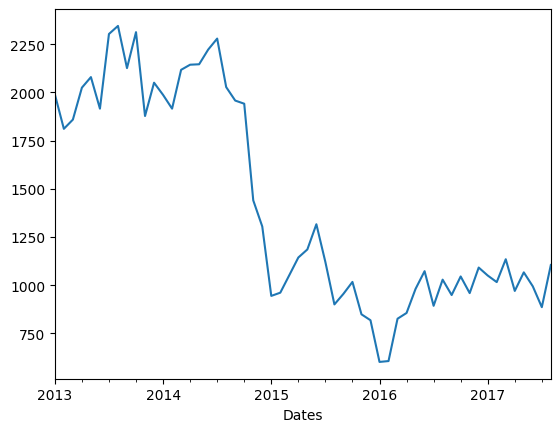

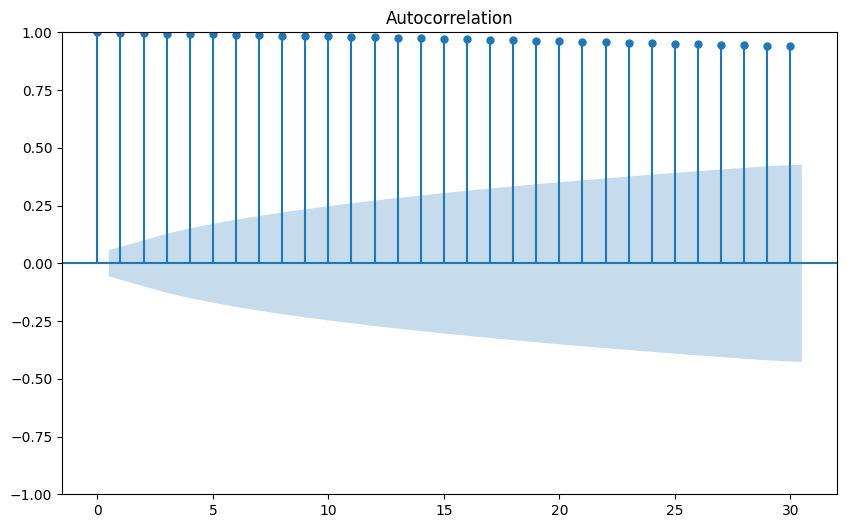

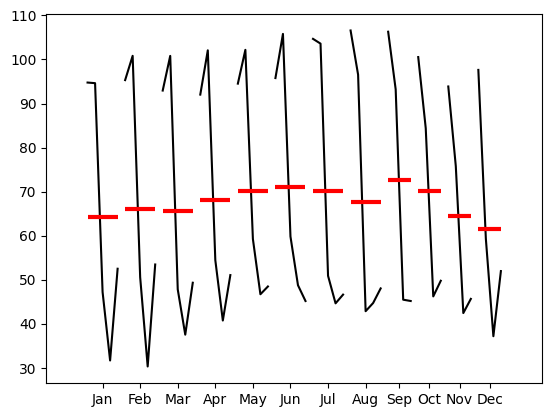

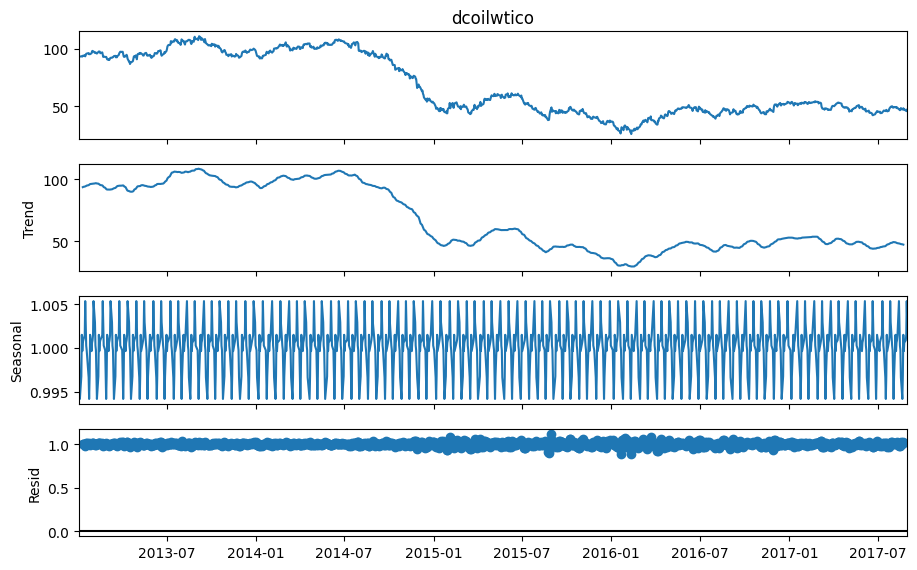

In [53]:
# lIBRARIES

import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Uploading File
df = pd.read_csv('oil.csv')
df.head()

# Understanding data
df.shape     # rows and columns
df.info()    # data types and missing values
df.describe() # stats

# Cleaning data
df.isnull().sum() # count missing values
df = df.dropna(subset=['dcoilwtico']) # remove holidays or weekends
df['dcoilwtico'] = df['dcoilwtico'].ffill() # carry last known price forward
df['dcoilwtico'] = df['dcoilwtico'].fillna(df['dcoilwtico'].mean()) #fill missing values with mean



# Time series index
df['Dates'] = pd.to_datetime(df['date'])
df.set_index('Dates',inplace=True)
df['dcoilwtico'] = df['dcoilwtico'].astype(float)
df.head()


# Resampling to monthly frequency
# Calculate the mean closing price
df['dcoilwtico'].resample('ME').mean()

# 30 day rolling average of average price
df['30_day_rolling'] = df['dcoilwtico'].rolling(window=30).mean()
df[['dcoilwtico','30_day_rolling']].plot()
plt.show()

# Highest average month
df['dcoilwtico'] = pd.to_numeric(df['dcoilwtico'], errors='coerce')
highestMonth = df['dcoilwtico'].resample('ME').mean().idxmax()
print('Month with highest average: ',highestMonth)

# Daily returns
df['daily_returns'] = df['dcoilwtico'].pct_change() * 100

# Days with more that 10% change in price
df[df['daily_returns'] > 10].head()

# Daily price
df['dcoilwtico'].plot(title='Daily Prices')
plt.show()

# Monthly volume
df.resample('ME').sum()['dcoilwtico'].plot()
plt.show()

# Correlation with 30-day rolling volume and the Prices 
df[['dcoilwtico','30_day_rolling']].corr()

# Autocorrelation 
fig,ax = plt.subplots(figsize=(10,6))
plot_acf(df['dcoilwtico'], lags=30,ax=ax)
plt.show()

# Seasonality
#Plot monthly sesonality
month_plot(df['dcoilwtico'].resample('ME').mean())
plt.show()

# Seasonal decomposition plots fro Net gas data
decomposition = seasonal_decompose(df['dcoilwtico'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.set_size_inches(10,6);
plt.show()


